# Лабораторная работа №4

## Обучение и анализ модели SARIMA для ряда солнечной активности

Используем данные из лабораторной работы №3.
Для поиска модели берем границы параметров, полученные ранее:

- `max_p = 6`
- `d = 0`
- `max_q = 0`
- `max_P = 0`
- `D = 0`
- `max_Q = 1`
- `season_length = 132`

Для кросс-валидации используем последние `396` месяцев обучающей выборки, то есть `3` солнечных цикла.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('tab10')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')


## 1. Загрузка данных

Загружаем предобработанные `train` и `test` из лабораторной работы №2.
В столбце `Sunspots` после интерполяции встречаются два отрицательных значения, поэтому перед моделированием ограничим ряд снизу нулем.


In [2]:
train = pd.read_csv('Analyze/lab_2/sunspots_train_preprocessed.csv', parse_dates=['Month'])
test = pd.read_csv('Analyze/lab_2/sunspots_test_preprocessed.csv', parse_dates=['Month'])

negative_before_clip = int((train['Sunspots'] < 0).sum() + (test['Sunspots'] < 0).sum())

for df in (train, test):
    df['Sunspots'] = df['Sunspots'].clip(lower=0)

series = train.set_index('Month')['Sunspots'].asfreq('MS')
test_series = test.set_index('Month')['Sunspots'].asfreq('MS')
full_series = pd.concat([series, test_series])

summary_df = pd.DataFrame({
    'dataset': ['train', 'test'],
    'start': [series.index.min(), test_series.index.min()],
    'end': [series.index.max(), test_series.index.max()],
    'n_obs': [len(series), len(test_series)],
})

display(summary_df)
print(f'Количество отрицательных значений до clip: {negative_before_clip}')
print(f'Итоговый размер полного ряда: {len(full_series)} наблюдений')


,dataset,start,end,n_obs
0,train,1749-01-01,1925-03-01,2115
1,test,1925-04-01,1983-12-01,705


Количество отрицательных значений до clip: 2
Итоговый размер полного ряда: 2820 наблюдений


## 2. Подготовка данных для кросс-валидации

Из лабораторной работы №3 берем оценки параметров и используем их как границы поиска.

Для `StatsForecast.cross_validation(...)` оставляем последние `396` месяцев train. Этого достаточно, чтобы в выборке было несколько полных циклов и модель считалась за разумное время.


In [3]:
max_p, d, max_q = 6, 0, 0
max_P, D, max_Q, season_length = 0, 0, 1, 132

cv_train = train[['Month', 'Sunspots']].rename(columns={'Month': 'ds', 'Sunspots': 'y'}).copy()
cv_train['unique_id'] = 'sunspots'
cv_train = cv_train[['unique_id', 'ds', 'y']].iloc[-396:].reset_index(drop=True)

cv_info = pd.DataFrame({
    'start': [cv_train['ds'].min()],
    'end': [cv_train['ds'].max()],
    'n_obs': [len(cv_train)],
    'season_length': [season_length],
    'cycles_in_cv_train': [len(cv_train) / season_length],
})

display(cv_info)


,start,end,n_obs,season_length,cycles_in_cv_train
0,1892-04-01,1925-03-01,396,132,3.0000


## 3. Кросс-валидация с AutoARIMA из `statsforecast`

Ищем модель в пределах параметров из лабораторной работы №3.

Для кросс-валидации берем:
- `h = 12`
- `step_size = 12`
- `n_windows = 5`

Так мы получаем несколько прогнозов на год вперед и смотрим, как меняется ошибка.


In [4]:
cv_model = AutoARIMA(
    d=d,
    D=D,
    season_length=season_length,
    start_p=0,
    start_q=0,
    start_P=0,
    start_Q=0,
    max_p=max_p,
    max_q=max_q,
    max_P=max_P,
    max_Q=max_Q,
    max_order=max_p,
    stepwise=True,
    nmodels=12,
    approximation=True,
    trace=False,
)

cv_forecaster = StatsForecast(models=[cv_model], freq='MS', n_jobs=1)

cv_start = time.perf_counter()
cv_results = cv_forecaster.cross_validation(
    df=cv_train,
    h=12,
    step_size=12,
    n_windows=5,
)
cv_elapsed_sec = time.perf_counter() - cv_start

cv_results['error'] = cv_results['y'] - cv_results['AutoARIMA']
cv_results['abs_error'] = cv_results['error'].abs()
cv_results['squared_error'] = cv_results['error'] ** 2
cv_results['ape'] = np.where(
    cv_results['y'] != 0,
    np.abs(cv_results['error'] / cv_results['y']) * 100,
    np.nan,
)
cv_results['smape'] = 100 * 2 * np.abs(cv_results['error']) / (
    np.abs(cv_results['y']) + np.abs(cv_results['AutoARIMA'])
)

cv_metrics = pd.DataFrame({
    'MAE': [cv_results['abs_error'].mean()],
    'RMSE': [np.sqrt(cv_results['squared_error'].mean())],
    'MAPE': [cv_results['ape'].dropna().mean()],
    'SMAPE': [cv_results['smape'].replace([np.inf, -np.inf], np.nan).dropna().mean()],
    'fit_time_sec': [cv_elapsed_sec],
})

cv_by_cutoff = cv_results.groupby('cutoff')[['abs_error', 'squared_error', 'ape', 'smape']].mean()
cv_by_cutoff = cv_by_cutoff.rename(columns={
    'abs_error': 'MAE_by_window',
    'squared_error': 'MSE_by_window',
    'ape': 'MAPE_by_window',
    'smape': 'SMAPE_by_window',
})

print('Первые строки результатов cross-validation:')
display(cv_results.head())
print('Сводные метрики по всем rolling forecast прогнозам:')
display(cv_metrics.round(4))
print('Средние ошибки по отдельным окнам кросс-валидации:')
display(cv_by_cutoff.round(4))


Первые строки результатов cross-validation:


,unique_id,ds,cutoff,y,AutoARIMA,error,abs_error,squared_error,ape,smape
0,sunspots,1920-04-01,1920-03-01,14.8000,59.6342,-44.8342,44.8342,"2,010.1069",302.9339,120.4667
1,sunspots,1920-05-01,1920-03-01,33.3000,57.5865,-24.2865,24.2865,589.8341,72.9324,53.4436
2,sunspots,1920-06-01,1920-03-01,38.7000,53.5960,-14.8960,14.8960,221.8894,38.4908,32.2787
3,sunspots,1920-07-01,1920-03-01,27.5000,56.3880,-28.8880,28.8880,834.5154,105.0472,68.8728
4,sunspots,1920-08-01,1920-03-01,19.2000,54.5566,-35.3566,35.3566,"1,250.0867",184.1488,95.8737


Сводные метрики по всем rolling forecast прогнозам:


,MAE,RMSE,MAPE,SMAPE,fit_time_sec
0,16.8677,20.0797,274.9023,80.4275,1.3263


Средние ошибки по отдельным окнам кросс-валидации:


,MAE_by_window,MSE_by_window,MAPE_by_window,SMAPE_by_window
cutoff,,,,
1920-03-01,25.4402,732.0504,102.5066,61.6166
1921-03-01,11.3832,166.6756,55.0669,40.8144
1922-03-01,29.5966,894.6099,637.0656,136.6504
1923-03-01,6.1270,58.2890,519.3812,83.4539
1924-03-01,11.7917,164.3473,60.4914,79.6022


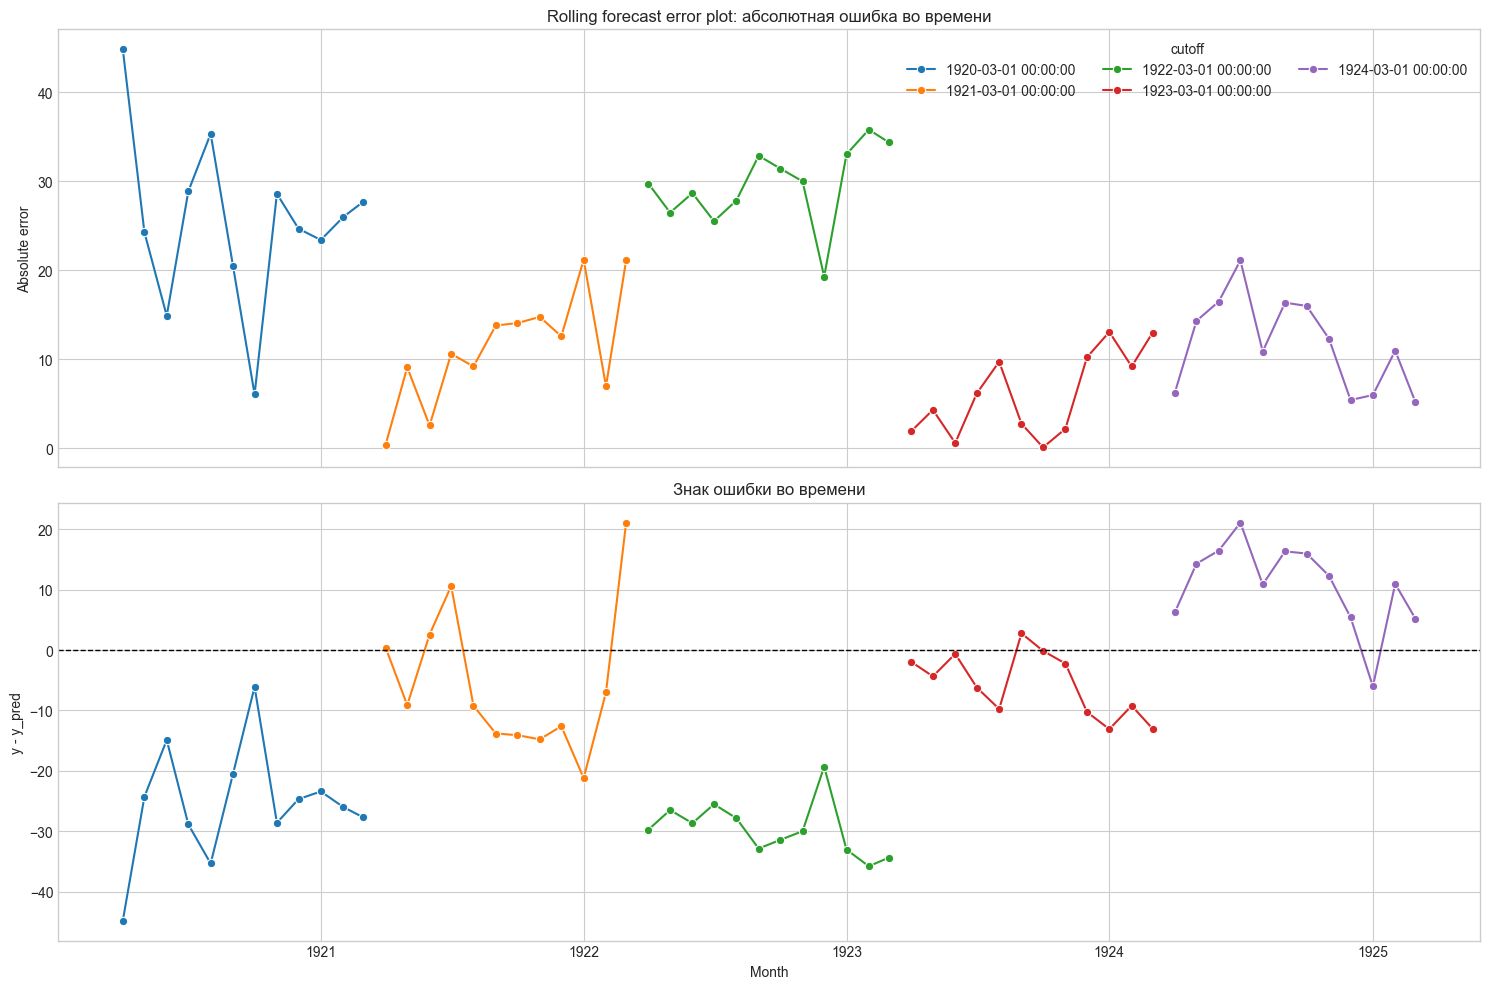

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

sns.lineplot(
    data=cv_results,
    x='ds',
    y='abs_error',
    hue='cutoff',
    marker='o',
    ax=axes[0],
)
axes[0].set_title('Rolling forecast error plot: абсолютная ошибка во времени')
axes[0].set_xlabel('')
axes[0].set_ylabel('Absolute error')
axes[0].legend(title='cutoff', ncol=3)

sns.lineplot(
    data=cv_results,
    x='ds',
    y='error',
    hue='cutoff',
    marker='o',
    ax=axes[1],
    legend=False,
)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Знак ошибки во времени')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('y - y_pred')

plt.tight_layout()
plt.show()


### Вывод по кросс-валидации

По графику видно, что ошибка сильно меняется от окна к окну. Значит, качество прогноза нестабильное.

Результат в целом слабый: модель иногда попадает в поведение ряда, но в других окнах ошибается заметно сильнее.

`MAPE` здесь получается слишком большим из-за значений, близких к нулю, поэтому полезнее смотреть на `MAE`, `RMSE` и `SMAPE`.


## 4. Повторное обучение AutoARIMA и выбор лучших параметров

Теперь обучаем `AutoARIMA` на тех же `396` наблюдениях, на которых выполнялась кросс-валидация, и извлекаем лучшую конфигурацию.


In [6]:
auto_model = AutoARIMA(
    d=d,
    D=D,
    season_length=season_length,
    start_p=0,
    start_q=0,
    start_P=0,
    start_Q=0,
    max_p=max_p,
    max_q=max_q,
    max_P=max_P,
    max_Q=max_Q,
    max_order=max_p,
    stepwise=True,
    nmodels=12,
    approximation=True,
    trace=False,
)

auto_forecaster = StatsForecast(models=[auto_model], freq='MS', n_jobs=1)

auto_start = time.perf_counter()
auto_forecaster.fit(cv_train)
auto_elapsed_sec = time.perf_counter() - auto_start

model_info = auto_forecaster.fitted_[0][0].model_
p_best, q_best, P_best, Q_best, s_best, d_best, D_best = model_info['arma']

best_params = pd.DataFrame({
    'parameter': ['p', 'd', 'q', 'P', 'D', 'Q', 's', 'AICc', 'BIC', 'fit_time_sec'],
    'value': [p_best, d_best, q_best, P_best, D_best, Q_best, s_best, model_info['aicc'], model_info['bic'], auto_elapsed_sec],
})

display(best_params)
print('Найденная AutoARIMA модель:')
print(f'SARIMA({p_best}, {d_best}, {q_best}) x ({P_best}, {D_best}, {Q_best}, {s_best})')


,parameter,value
0,p,4.0000
1,d,0.0000
2,q,0.0000
3,P,0.0000
4,D,0.0000
5,Q,1.0000
6,s,132.0000
7,AICc,"3,247.4752"
8,BIC,"3,275.0564"
9,fit_time_sec,72.2698


Найденная AutoARIMA модель:
SARIMA(4, 0, 0) x (0, 0, 1, 132)


### Выбранная модель

`AutoARIMA` выбрала модель:

`SARIMA(4, 0, 0) x (0, 0, 1, 132)`

Она проще, чем модель из лабораторной работы №3, но того же типа: обычная AR-часть и сезонная MA-часть с периодом `132` месяца.


## 5. Обучение итоговой модели в `statsmodels`

По условию задания строим модель с лучшими параметрами уже в `statsmodels`, выводим `summary()` и анализируем значимость коэффициентов.


In [7]:
sm_start = time.perf_counter()
final_model = SARIMAX(
    series,
    order=(p_best, d_best, q_best),
    seasonal_order=(P_best, D_best, Q_best, s_best),
    trend='c',
    enforce_stationarity=False,
    enforce_invertibility=False,
    concentrate_scale=True,
)
final_result = final_model.fit(method='lbfgs', maxiter=200, disp=False)
sm_elapsed_min = (time.perf_counter() - sm_start) / 60

print(f'Время обучения statsmodels-модели: {sm_elapsed_min:.2f} мин')
print(final_result.summary())


Время обучения statsmodels-модели: 2.35 мин
                                       SARIMAX Results                                       
Dep. Variable:                              Sunspots   No. Observations:                 2115
Model:             SARIMAX(4, 0, 0)x(0, 0, [1], 132)   Log Likelihood               -8099.708
Date:                               Thu, 07 May 2026   AIC                          16213.417
Time:                                       11:49:47   BIC                          16252.560
Sample:                                   01-01-1749   HQIC                         16227.796
                                        - 03-01-1925   Scale                          207.523
Covariance Type:                                 opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      2.0595      0.744      2.770   

In [8]:
coef_table = pd.concat([
    final_result.params.rename('coef'),
    final_result.bse.rename('std_err'),
    final_result.pvalues.rename('p_value'),
    final_result.conf_int().rename(columns={0: 'ci_low', 1: 'ci_high'}),
], axis=1)
coef_table['significant_05'] = coef_table['p_value'] < 0.05

lb_table = acorr_ljungbox(final_result.resid.dropna(), lags=[12, 24, 36], return_df=True)

print('Таблица коэффициентов:')
display(coef_table.round(6))
print('Ljung-Box для остатков:')
display(lb_table.round(6))


Таблица коэффициентов:


,coef,std_err,p_value,ci_low,ci_high,significant_05
intercept,2.0595,0.7436,0.0056,0.6021,3.5169,True
ar.L1,0.5624,0.0172,0.0000,0.5287,0.5960,True
ar.L2,0.1370,0.0190,0.0000,0.0998,0.1742,True
ar.L3,0.1363,0.0214,0.0000,0.0942,0.1783,True
ar.L4,0.1174,0.0193,0.0000,0.0795,0.1553,True
ma.S.L132,0.0475,0.0209,0.0228,0.0066,0.0884,True


Ljung-Box для остатков:


,lb_stat,lb_pvalue
12,51.6797,0.0000
24,85.3978,0.0000
36,106.9111,0.0000


### Вывод по коэффициентам

Все коэффициенты значимы: `p-value < 0.05`, а доверительные интервалы не содержат ноль.

Это хороший признак, но сам по себе он еще не означает, что модель получилась качественной.


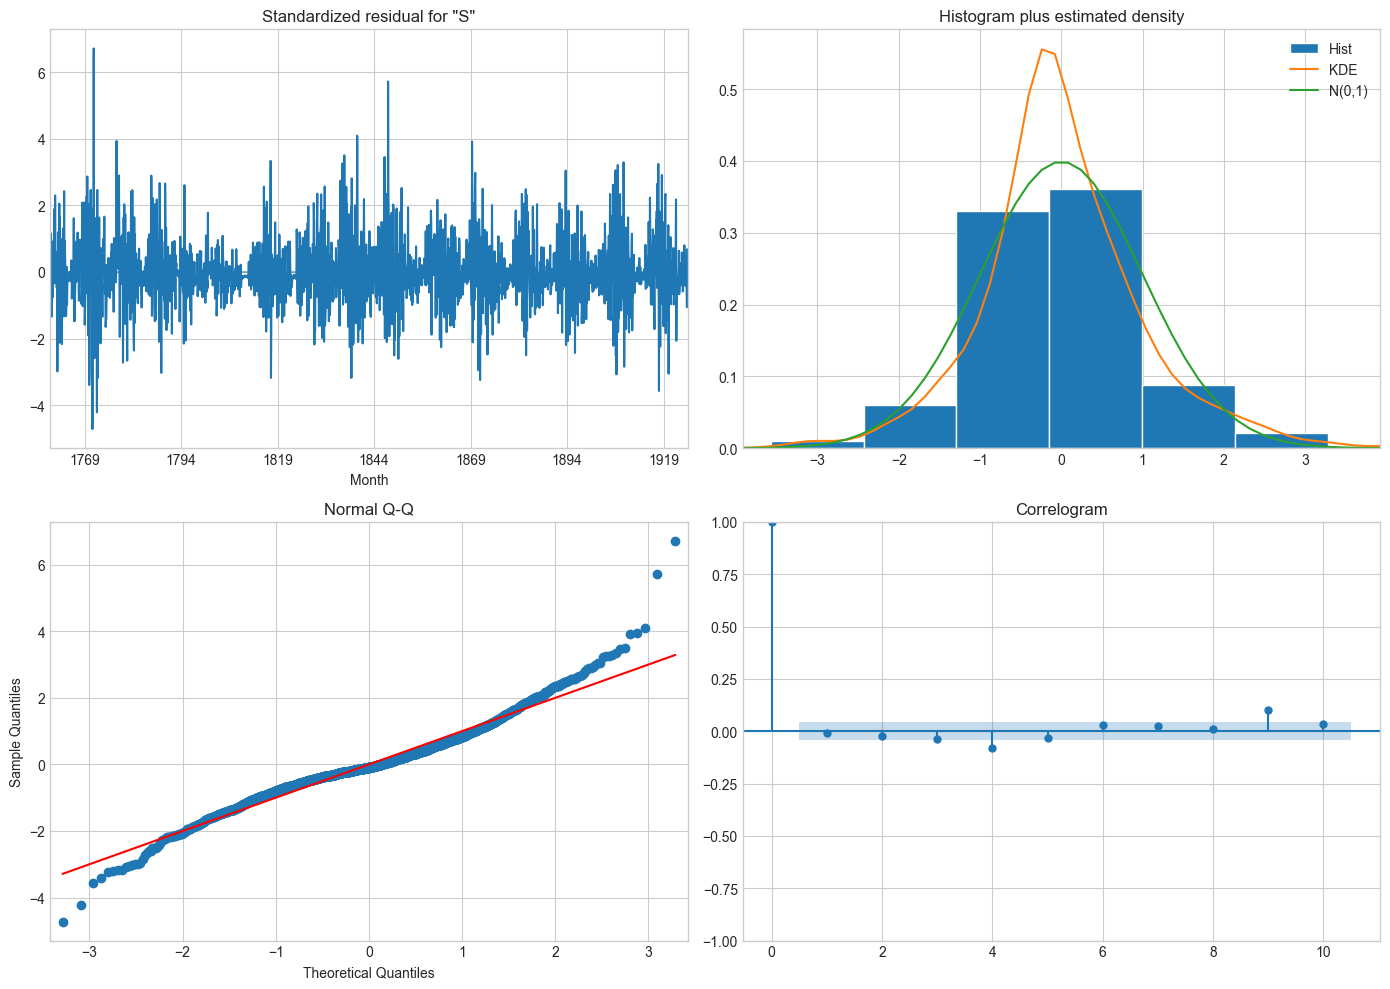

In [9]:
final_result.plot_diagnostics(figsize=(14, 10))
plt.tight_layout()
plt.show()


### Вывод по диагностике остатков

Остатки нельзя считать случайными:
- сохраняется автокорреляция;
- `p-value` теста Ljung-Box малы;
- распределение ошибок отличается от нормального.

То есть модель описывает ряд не очень хорошо.


## 6. Прогноз на тестовой выборке и метрики качества


In [10]:
forecast = final_result.get_forecast(steps=len(test_series))
pred = forecast.predicted_mean
pred.index = test_series.index
conf_int = forecast.conf_int()
conf_int.index = test_series.index

mae = mean_absolute_error(test_series, pred)
mse = mean_squared_error(test_series, pred)
mask = test_series != 0
mape = (np.abs((test_series[mask] - pred[mask]) / test_series[mask]).mean() * 100)
smape = (
    100
    * (2 * np.abs(pred - test_series) / (np.abs(test_series) + np.abs(pred)))
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .mean()
)

metrics = pd.DataFrame({
    'MAE': [mae],
    'MSE': [mse],
    'MAPE': [mape],
    'SMAPE': [smape],
})

display(metrics.round(4))


,MAE,MSE,MAPE,SMAPE
0,42.6581,"2,753.8114",300.3443,76.3452


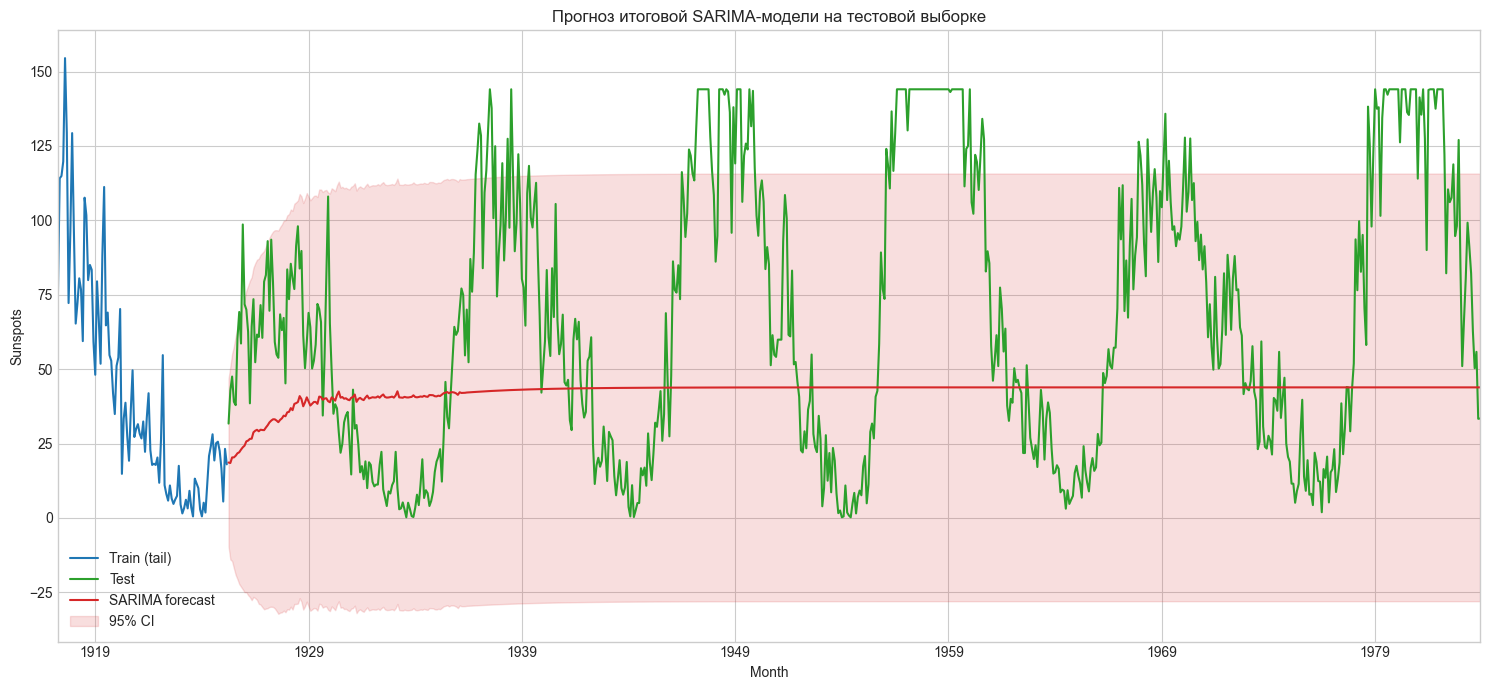

In [11]:
fig, ax = plt.subplots(figsize=(15, 7))
series.iloc[-8 * 12:].plot(ax=ax, label='Train (tail)', color='tab:blue')
test_series.plot(ax=ax, label='Test', color='tab:green')
pred.plot(ax=ax, label='SARIMA forecast', color='tab:red')
ax.fill_between(
    conf_int.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color='tab:red',
    alpha=0.15,
    label='95% CI',
)
ax.set_title('Прогноз итоговой SARIMA-модели на тестовой выборке')
ax.set_xlabel('Month')
ax.set_ylabel('Sunspots')
ax.legend()
plt.tight_layout()
plt.show()


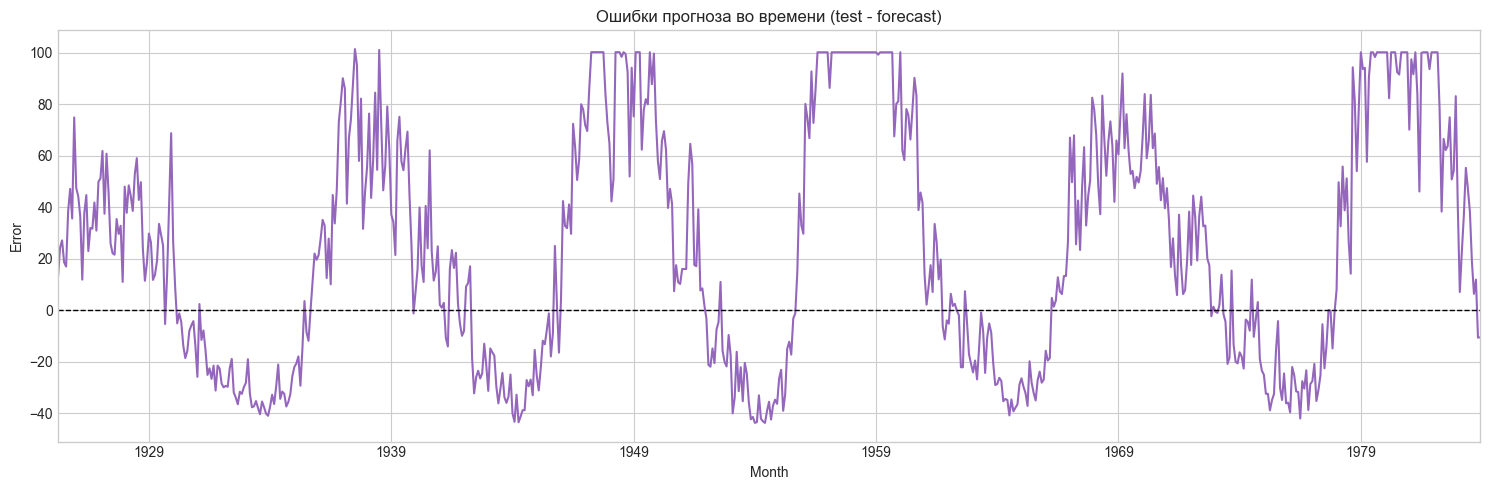

In [12]:
forecast_errors = (test_series - pred).rename('forecast_error')

fig, ax = plt.subplots(figsize=(15, 5))
forecast_errors.plot(ax=ax, color='tab:purple')
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('Ошибки прогноза во времени (test - forecast)')
ax.set_xlabel('Month')
ax.set_ylabel('Error')
plt.tight_layout()
plt.show()


## 7. Итоговый вывод

1. Для кросс-валидации использовались `statsforecast` и `AutoARIMA`.
2. Обучающая выборка была сокращена до последних `396` месяцев.
3. Лучшая модель по `AutoARIMA`: `SARIMA(4, 0, 0) x (0, 0, 1, 132)`.
4. Коэффициенты модели в `statsmodels` значимы.
5. По остаткам видно, что модель не описывает ряд полностью.
6. Качество прогноза получилось слабым и нестабильным.
7. Метрики `MAE`, `MSE`, `MAPE`, `SMAPE` рассчитаны, но `MAPE` здесь завышается из-за значений ряда, близких к нулю.


## 8. Дополнительный эксперимент: агрегация по годам

В задании допускается ускорение и упрощение модели через изменение частоты ряда. В качестве дополнительного эксперимента агрегируем месячные данные по годам, усредняя значения внутри каждого года.

После агрегации:
- частота становится годовой;
- сезонный лаг естественно принять равным `11`, так как цикл солнечной активности составляет примерно 11 лет;
- для кросс-валидации используем последние `66` лет, то есть `6` полных циклов.


In [13]:
annual_train = train.set_index('Month')['Sunspots'].resample('YS').mean()
annual_test = test.set_index('Month')['Sunspots'].resample('YS').mean()

annual_cv_train = annual_train.iloc[-66:].reset_index()
annual_cv_train = annual_cv_train.rename(columns={'Month': 'ds', 'Sunspots': 'y'})
annual_cv_train['unique_id'] = 'sunspots_yearly'
annual_cv_train = annual_cv_train[['unique_id', 'ds', 'y']]

annual_model = AutoARIMA(
    d=0,
    D=0,
    season_length=11,
    start_p=0,
    start_q=0,
    start_P=0,
    start_Q=0,
    max_p=3,
    max_q=2,
    max_P=1,
    max_Q=1,
    max_order=5,
    stepwise=True,
    nmodels=30,
    approximation=True,
    trace=False,
)

annual_sf = StatsForecast(models=[annual_model], freq='YS', n_jobs=1)

annual_cv_start = time.perf_counter()
annual_cv_results = annual_sf.cross_validation(
    df=annual_cv_train,
    h=3,
    step_size=3,
    n_windows=5,
)
annual_cv_sec = time.perf_counter() - annual_cv_start

annual_cv_results['error'] = annual_cv_results['y'] - annual_cv_results['AutoARIMA']
annual_cv_results['abs_error'] = annual_cv_results['error'].abs()
annual_cv_results['squared_error'] = annual_cv_results['error'] ** 2
annual_cv_results['smape'] = 100 * 2 * np.abs(annual_cv_results['error']) / (
    np.abs(annual_cv_results['y']) + np.abs(annual_cv_results['AutoARIMA'])
)

annual_cv_metrics = pd.DataFrame({
    'model': ['monthly base', 'annual aggregated'],
    'MAE': [
        cv_results['abs_error'].mean(),
        annual_cv_results['abs_error'].mean(),
    ],
    'RMSE': [
        np.sqrt(cv_results['squared_error'].mean()),
        np.sqrt(annual_cv_results['squared_error'].mean()),
    ],
    'SMAPE': [
        cv_results['smape'].replace([np.inf, -np.inf], np.nan).dropna().mean(),
        annual_cv_results['smape'].replace([np.inf, -np.inf], np.nan).dropna().mean(),
    ],
    'cv_time_sec': [
        cv_elapsed_sec,
        annual_cv_sec,
    ],
})

annual_fit = StatsForecast(models=[annual_model], freq='YS', n_jobs=1)
annual_fit.fit(annual_cv_train)
annual_info = annual_fit.fitted_[0][0].model_
annual_p, annual_q, annual_P, annual_Q, annual_s, annual_d, annual_D = annual_info['arma']

annual_params = pd.DataFrame({
    'parameter': ['p', 'd', 'q', 'P', 'D', 'Q', 's', 'AICc', 'BIC'],
    'value': [
        annual_p,
        annual_d,
        annual_q,
        annual_P,
        annual_D,
        annual_Q,
        annual_s,
        annual_info['aicc'],
        annual_info['bic'],
    ],
})

display(annual_cv_metrics.round(4))
display(annual_params)
print(
    'Annual AutoARIMA model:',
    f'SARIMA({annual_p}, {annual_d}, {annual_q}) x ({annual_P}, {annual_D}, {annual_Q}, {annual_s})'
)


,model,MAE,RMSE,SMAPE,cv_time_sec
0,monthly base,16.8677,20.0797,80.4275,1.3263
1,annual aggregated,10.8510,15.6224,46.3344,2.6752


,parameter,value
0,p,2.0000
1,d,0.0000
2,q,1.0000
3,P,1.0000
4,D,0.0000
5,Q,0.0000
6,s,11.0000
7,AICc,548.4724
8,BIC,560.1866


Annual AutoARIMA model: SARIMA(2, 0, 1) x (1, 0, 0, 11)


In [14]:
annual_series = annual_train.iloc[-66:]
annual_test_series = annual_test

annual_result = SARIMAX(
    annual_series,
    order=(annual_p, annual_d, annual_q),
    seasonal_order=(annual_P, annual_D, annual_Q, annual_s),
    trend='c',
    enforce_stationarity=False,
    enforce_invertibility=False,
    concentrate_scale=True,
).fit(method='lbfgs', maxiter=200, disp=False)

annual_forecast = annual_result.get_forecast(steps=len(annual_test_series))
annual_pred = annual_forecast.predicted_mean
annual_pred.index = annual_test_series.index
annual_ci = annual_forecast.conf_int()
annual_ci.index = annual_test_series.index

annual_mae = mean_absolute_error(annual_test_series, annual_pred)
annual_mse = mean_squared_error(annual_test_series, annual_pred)
annual_smape = (
    100
    * (2 * np.abs(annual_pred - annual_test_series) / (np.abs(annual_test_series) + np.abs(annual_pred)))
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .mean()
)

annual_metrics = pd.DataFrame({
    'MAE': [annual_mae],
    'MSE': [annual_mse],
    'SMAPE': [annual_smape],
})

display(annual_metrics.round(4))
print(annual_result.summary())


,MAE,MSE,SMAPE
0,42.5544,"2,968.1911",75.3199


                                      SARIMAX Results                                      
Dep. Variable:                            Sunspots   No. Observations:                   66
Model:             SARIMAX(2, 0, 1)x(1, 0, [], 11)   Log Likelihood                -198.128
Date:                             Thu, 07 May 2026   AIC                            408.255
Time:                                     11:49:53   BIC                            420.077
Sample:                                 01-01-1860   HQIC                           412.801
                                      - 01-01-1925   Scale                           95.906
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      8.5495      2.055      4.161      0.000       4.522      12.577
ar.L1          1.6089      

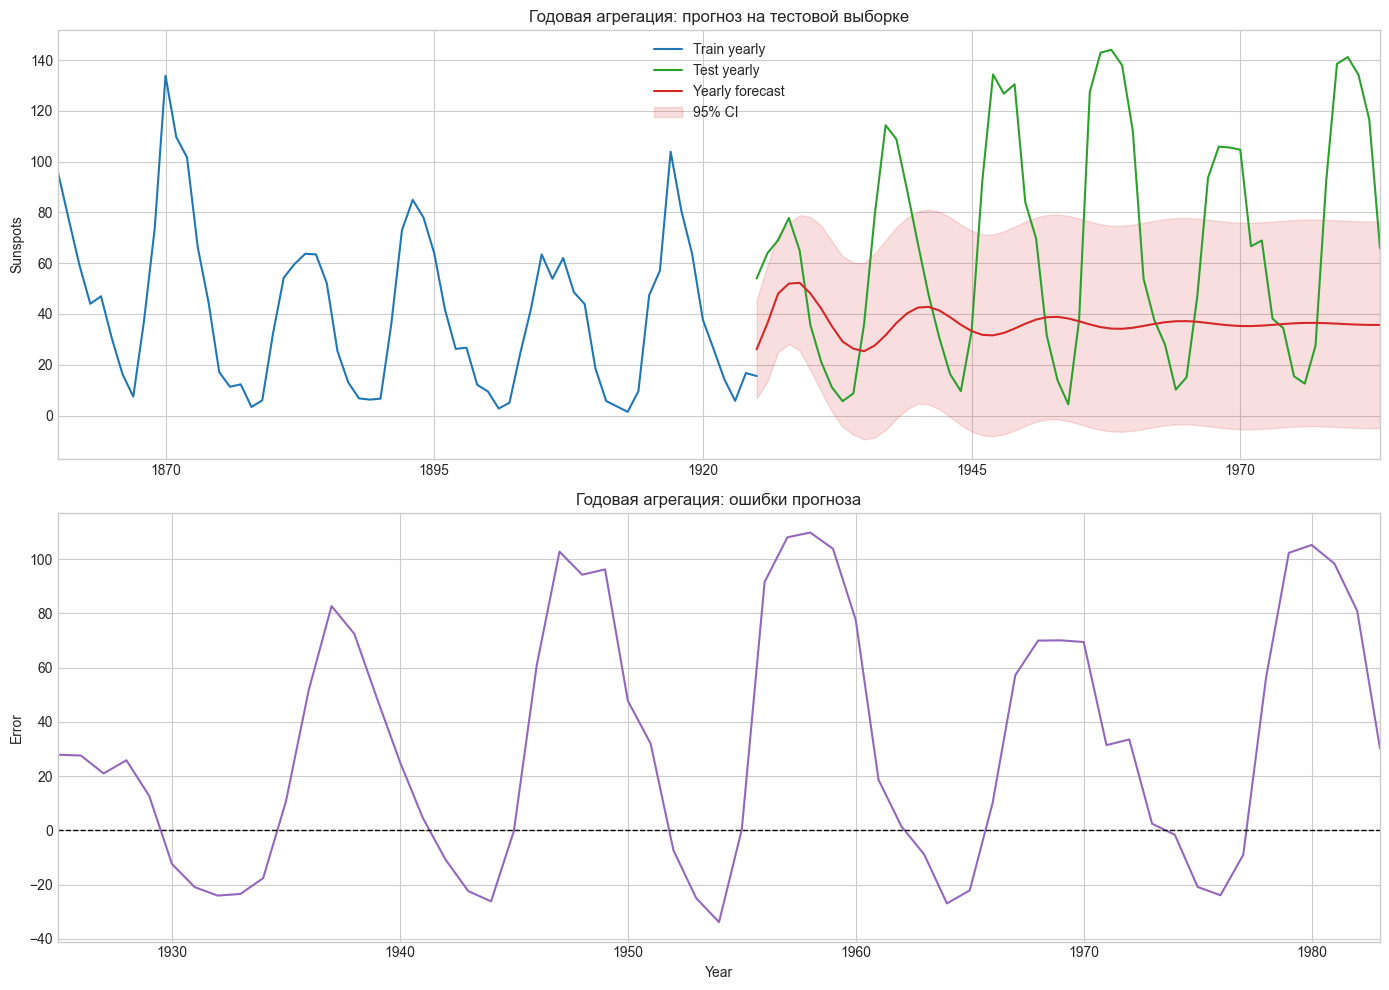

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

annual_series.plot(ax=axes[0], label='Train yearly', color='tab:blue')
annual_test_series.plot(ax=axes[0], label='Test yearly', color='tab:green')
annual_pred.plot(ax=axes[0], label='Yearly forecast', color='tab:red')
axes[0].fill_between(
    annual_ci.index,
    annual_ci.iloc[:, 0],
    annual_ci.iloc[:, 1],
    color='tab:red',
    alpha=0.15,
    label='95% CI',
)
axes[0].set_title('Годовая агрегация: прогноз на тестовой выборке')
axes[0].set_xlabel('')
axes[0].set_ylabel('Sunspots')
axes[0].legend()

(annual_test_series - annual_pred).rename('annual_error').plot(ax=axes[1], color='tab:purple')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Годовая агрегация: ошибки прогноза')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Error')

plt.tight_layout()
plt.show()


### Вывод по годовому эксперименту

После перехода к годовой агрегации модель стала компактнее, а кросс-валидационные метрики заметно улучшились. Прогноз остается неидеальным, но выглядит стабильнее, чем у месячной модели.

Такой дополнительный эксперимент показывает, что для данного ряда проблема связана не только с параметрами SARIMA, но и с самой частотой данных: на месячном ряде цикл получается слишком шумным, а на годовом — описывается заметно проще.
